In [24]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [25]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

### `Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.

In [26]:
# code here
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

In [27]:
df = pd.DataFrame(data, index=labels)
df.head(2)

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes


In [28]:
df.shape

(11, 4)

In [29]:
df.dtypes

birds           str
age         float64
visits        int64
priority        str
dtype: object

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     str    
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 561.0 bytes


In [31]:
df.iloc[::2]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


### `Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [32]:
# code here

df.iloc[[0, 2, 6], [0, 1]]

,birds,age
a,Cranes,3.5
c,plovers,1.5
g,plovers,5.5


In [33]:
df[df["visits"]<4]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no
k,Cranes,3.5,2,yes


### `Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [34]:
# code here
df[(df["age"].isnull()) | (df["visits"].isnull())]

,birds,age,visits,priority
d,spoonbills,NaN,4,NaN
h,Cranes,NaN,2,yes


In [35]:
df["age"] = df["age"].fillna(df["age"].mode()[0])
df["priority"] = df["priority"].fillna(df["priority"].mode()[0])

In [36]:
df.isnull().sum()

birds       0
age         0
visits      0
priority    0
dtype: int64

### `Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [37]:
# code here

df[df['birds']=='Cranes']['visits'].sum()

np.int64(14)

In [38]:
df["birds"].value_counts()

birds
Cranes        5
spoonbills    4
plovers       2
Name: count, dtype: int64

In [39]:
print(df.duplicated().sum())

2


In [40]:
df.drop_duplicates(inplace=True)
df

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,3.5,4,no
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


## Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

### `Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [41]:
# code here
df = pd.read_csv('data/17_data/ipl-matches.csv')


In [42]:
df.iloc[df["Team1"]=='Delhi Capitals', 5]='Delhi Daredevils'
df.iloc[df["Team2"]=='Delhi Capitals', 6]='Delhi Daredevils'
df.loc[df["Team1"]=='Punjab Kings', "Team1"]='Kings XI Punjab'
df.loc[df["Team2"]=='Punjab Kings', "Team2"]='Kings XI Punjab'
df.loc[df["Team1"]=='Rising Pune Supergiant', "Team1"]='Rising Pune Supergiants'
df.loc[df["Team2"]=='Rising Pune Supergiant', "Team2"]='Rising Pune Supergiants'

In [43]:
df["Team1"].unique()

<ArrowStringArray>
[           'Rajasthan Royals', 'Royal Challengers Bangalore',
         'Sunrisers Hyderabad',            'Delhi Daredevils',
         'Chennai Super Kings',              'Gujarat Titans',
        'Lucknow Super Giants',       'Kolkata Knight Riders',
             'Kings XI Punjab',              'Mumbai Indians',
     'Rising Pune Supergiants',               'Gujarat Lions',
               'Pune Warriors',             'Deccan Chargers',
        'Kochi Tuskers Kerala']
Length: 15, dtype: str

In [44]:

df["Team2"].unique()

<ArrowStringArray>
[             'Gujarat Titans',            'Rajasthan Royals',
        'Lucknow Super Giants',             'Kings XI Punjab',
              'Mumbai Indians', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders',         'Sunrisers Hyderabad',
            'Delhi Daredevils',         'Chennai Super Kings',
     'Rising Pune Supergiants',               'Gujarat Lions',
               'Pune Warriors',             'Deccan Chargers',
        'Kochi Tuskers Kerala']
Length: 15, dtype: str

### `Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


<Axes: xlabel='Team1'>

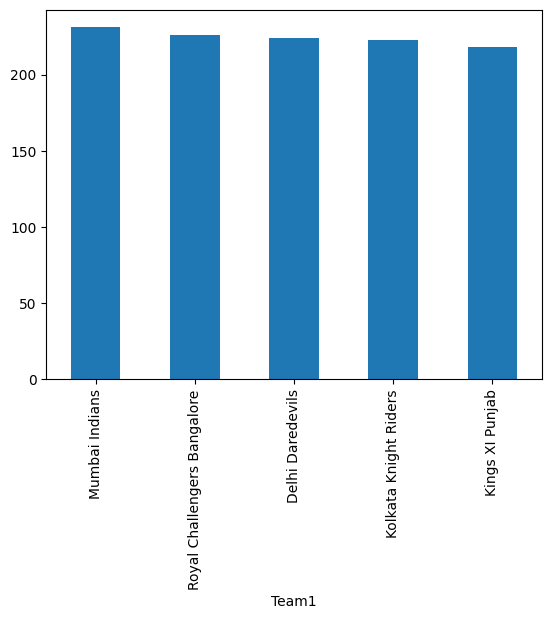

In [45]:
# code here

(df["Team1"].value_counts()+df["Team2"].value_counts()).sort_values(ascending=False).head(5).plot(kind="bar")

### `Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [46]:
# code here

mumbai = df[((df['Team1']=="Mumbai Indians")|(df['Team2']=="Mumbai Indians")) & (df["WinningTeam"]!='Mumbai Indians')]

In [47]:
mumbai["Player_of_Match"].value_counts().head(3)

Player_of_Match
KL Rahul     4
SPD Smith    4
SK Raina     4
Name: count, dtype: int64

### `Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [48]:
df.head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


'Total number of matches playes between Kolkata Knight Riders and Chennai Super Kings is 26 and the most repreated player of the match is RA Jadeja with 3'

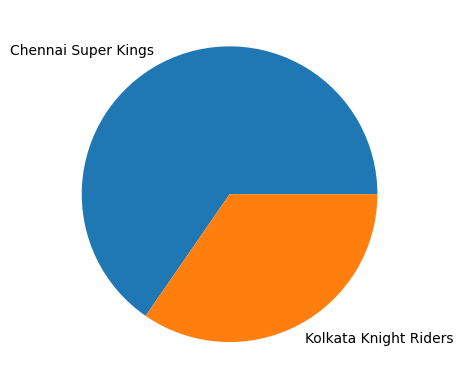

In [49]:
# code here

def win(team1, team2):
    fil = df[(df["Team1"]==team1) & (df["Team2"]==team2) | (df["Team1"]==team2) & (df["Team2"]==team1)]
    total_match = fil.shape[0]
    win_count = fil["WinningTeam"].value_counts().sort_values(ascending=False)
    player_match = fil["Player_of_Match"].value_counts().head(1)
    win_count.plot(kind="pie")
    
    return str(f"Total number of matches playes between {team1} and {team2} is {total_match} and the most repreated player of the match is {player_match.index[0]} with {player_match.values[0]}")
    

win('Kolkata Knight Riders', 'Chennai Super Kings')

### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



<Axes: xlabel='City'>

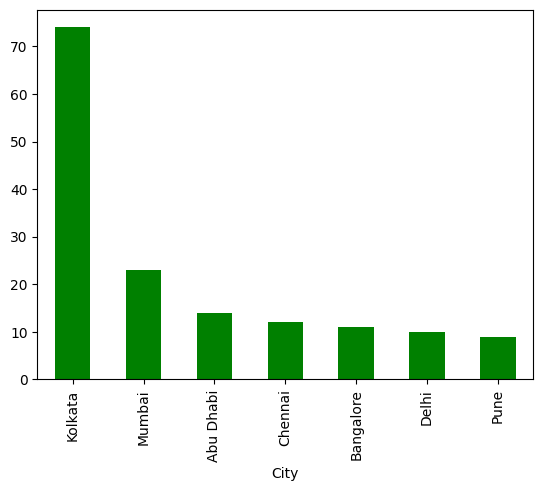

In [50]:
# code here

df.loc[(df["Team1"]=='Kolkata Knight Riders') | (df["Team2"]=='Kolkata Knight Riders'), "City"].value_counts()\
    .sort_values(ascending=False).head(7).plot(kind="bar", color="green")
    


### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [60]:
df["WinningTeam"].unique()

<ArrowStringArray>
[             'Gujarat Titans',            'Rajasthan Royals',
 'Royal Challengers Bangalore',                'Punjab Kings',
              'Mumbai Indians',        'Lucknow Super Giants',
         'Sunrisers Hyderabad',              'Delhi Capitals',
       'Kolkata Knight Riders',         'Chennai Super Kings',
             'Kings XI Punjab',                           nan,
            'Delhi Daredevils',      'Rising Pune Supergiant',
               'Gujarat Lions',     'Rising Pune Supergiants',
               'Pune Warriors',             'Deccan Chargers',
        'Kochi Tuskers Kerala']
Length: 19, dtype: str

In [82]:
# code here
(df.loc[(df["WinningTeam"]=="Mumbai Indians") & (df["Season"]=='2011')]["Margin"].mean())

np.float64(15.4)